# Financial Transaction Category Classification
**Team Members:** Ian Hock, Jaden Ong, Justin Pelak, Sawyer Jones
**Course:** CS549 - Machine Learning
**Dataset:** `aug_personal_transactions_with_UserId.csv`

---

## Abstract
This project classifies financial transactions into categories (Groceries, Restaurants, Utilities, etc.) using Logistic Regression, SVM, Neural Network (MLP), and KNN. We preprocess the data, extract features using TF-IDF, and evaluate all models with accuracy, precision, recall, F1-score, confusion matrices, and per-class analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
import time

plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_STATE = 42

## 1. Data Loading & Exploration
*(Sawyer Jones)*

In [2]:
raw = pd.read_csv('aug_personal_transactions_with_UserId.csv')
print(raw.shape)
raw.head(10)

(10806, 7)


,User ID,Date,Description,Amount,Transaction Type,Category,Account Name
0,2.0,1/1/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,1.0,1/2/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,3.0,1/2/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,2.0,1/3/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,2.0,1/4/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card
5,3.0,1/5/2018,American Tavern,25.85,debit,Restaurants,Silver Card
6,3.0,1/6/2018,Hardware Store,18.45,debit,Home Improvement,Silver Card
7,1.0,1/8/2018,Gas Company,45.00,debit,Utilities,Checking
8,3.0,1/8/2018,Hardware Store,15.38,debit,Home Improvement,Silver Card
9,2.0,1/9/2018,Spotify,10.69,debit,Music,Platinum Card


In [3]:
raw.dtypes

User ID             float64
Date                 object
Description          object
Amount              float64
Transaction Type     object
Category             object
Account Name         object
dtype: object

In [4]:
# check for missing values
raw.isnull().sum()

User ID             10000
Date                    0
Description             0
Amount                  0
Transaction Type        0
Category                0
Account Name            0
dtype: int64

In [5]:
# User ID has 10000 NaN values - seems intentional, not a data error
# lets look at what those rows actually look like
print(raw['User ID'].value_counts(dropna=False))
print()
print('rows with User ID:', raw['User ID'].notna().sum())
print('rows without User ID:', raw['User ID'].isna().sum())

User ID
NaN    10000
2.0      366
1.0      264
3.0      176
Name: count, dtype: int64

rows with User ID: 806
rows without User ID: 10000


In [6]:
# the rows missing User ID have scrambled/random category labels
# ex: Netflix labeled as Coffee Shops, Credit Card Payment labeled as Utilities
# these are clearly augmented noise rows - we need to drop them
raw[raw['User ID'].isna()][['Description', 'Category', 'Transaction Type']].sample(10, random_state=1)

,Description,Category,Transaction Type
10759,Biweekly Paycheck,Movies & DVDs,credit
4656,Netflix,Coffee Shops,debit
5768,Brewing Company,Coffee Shops,credit
4692,Hardware Store,Restaurants,credit
6243,Gas Company,Movies & DVDs,credit
9323,Roadside Diner,Credit Card Payment,credit
2847,Credit Card Payment,Utilities,debit
2795,Grocery Store,Credit Card Payment,debit
2739,State Farm,Shopping,credit
10790,Credit Card Payment,Home Improvement,credit


## 2. Data Preprocessing
*(Jaden Ong)*

In [7]:
# only keep the 806 cleanly labeled rows after looking at the data, the rest are just noise
# we can see some rows with State Farm labeled as Restaurants, or Netflix as Paycheck.
df = raw[raw['User ID'].notna()].copy()
print(f'working with {len(df)} labeled rows')

df = df.dropna(subset=['Category', 'Description'])

# remove duplicates
n_before = len(df)
df = df.drop_duplicates()
print(f'duplicates removed: {n_before - len(df)}')

working with 806 labeled rows
duplicates removed: 0


In [8]:
# fill any remaining missing values
df = df.assign(
    **{
        'Transaction Type': df['Transaction Type'].fillna('unknown'),
        'Account Name':     df['Account Name'].fillna('unknown'),
        'Amount':           df['Amount'].fillna(df['Amount'].median()),
    }
)

# normalize text so 'Amazon' and 'amazon' are the same token
df = df.assign(
    Description      = df['Description'].str.lower().str.strip(),
    Category         = df['Category'].str.strip(),
    **{'Transaction Type': df['Transaction Type'].str.lower().str.strip()},
    **{'Account Name':     df['Account Name'].str.lower().str.strip()},
)

In [9]:
# check category distribution before filtering
df['Category'].value_counts()

Category
Credit Card Payment       143
Groceries                 105
Restaurants                81
Utilities                  63
Shopping                   60
Gas & Fuel                 52
Paycheck                   46
Home Improvement           36
Coffee Shops               31
Alcohol & Bars             25
Internet                   21
Mortgage & Rent            21
Mobile Phone               21
Music                      21
Movies & DVDs              18
Auto Insurance             18
Fast Food                  16
Haircut                    13
Television                  8
Electronics & Software      4
Food & Dining               2
Entertainment               1
Name: count, dtype: int64

In [10]:
# drop categories with < 10 samples - cant do stratified split otherwise
cat_counts = df['Category'].value_counts()
valid_cats = cat_counts[cat_counts >= 10].index

n_before = len(df)
df = df[df['Category'].isin(valid_cats)]
print(f'dropped {n_before - len(df)} rows from rare categories')
print(f'final: {df.shape[0]} rows, {df["Category"].nunique()} categories')

dropped 15 rows from rare categories
final: 791 rows, 18 categories


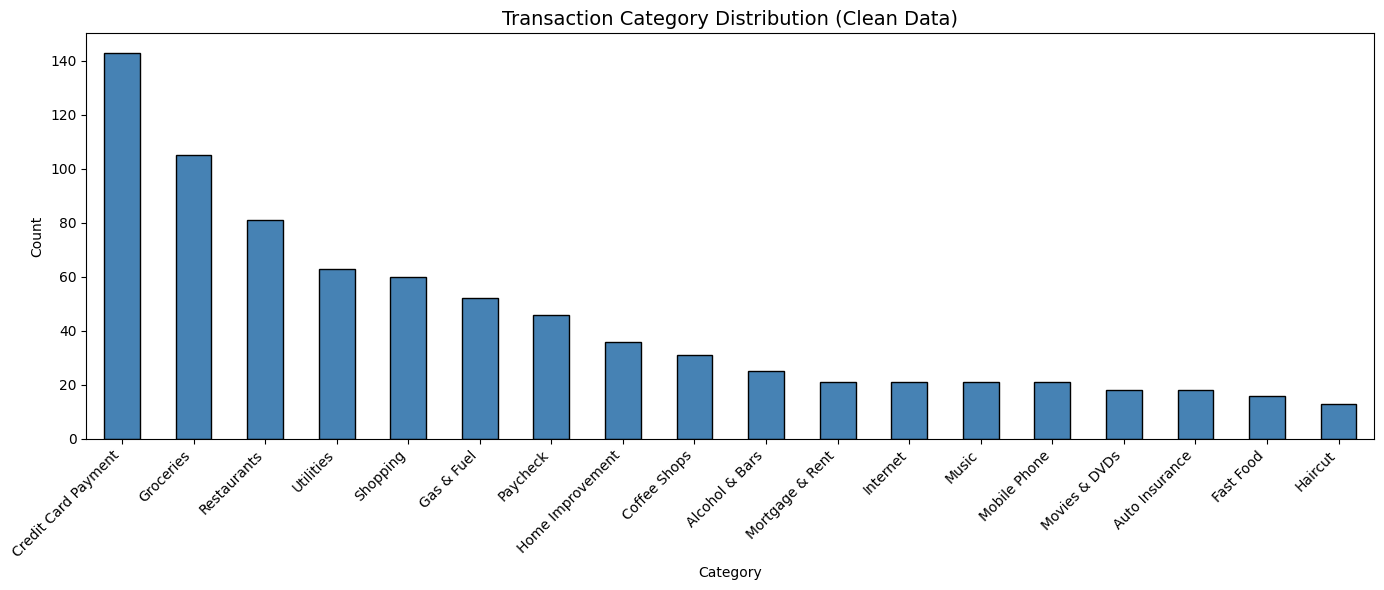

In [11]:
plt.figure(figsize=(14, 6))
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Transaction Category Distribution (Clean Data)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150)
plt.show()

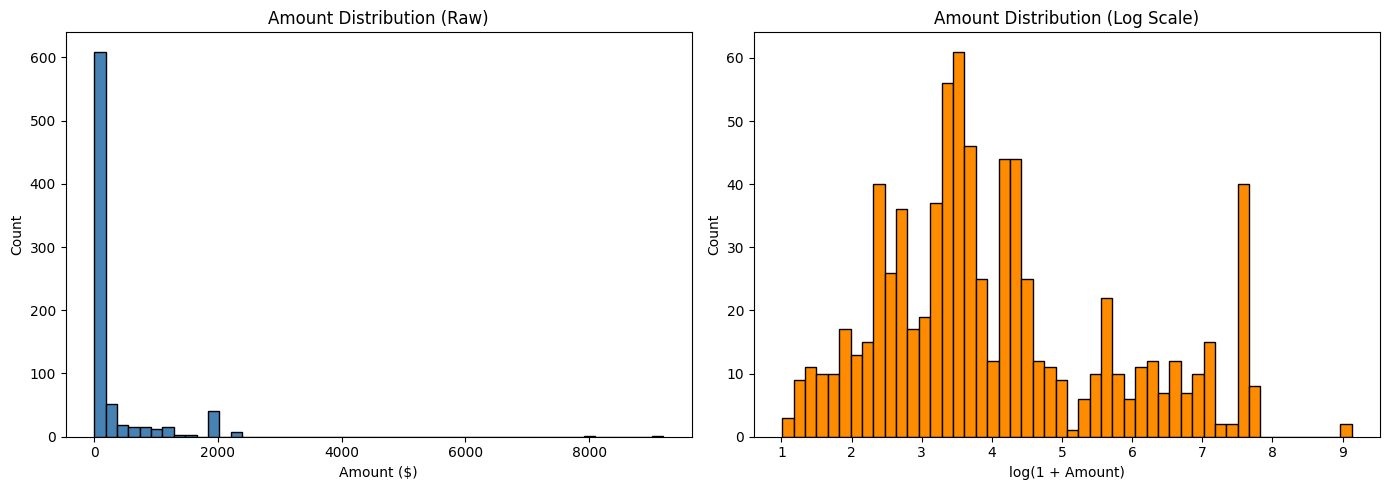

In [12]:
# amount is right skewed, log transform will help
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Amount Distribution (Raw)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['Amount']), bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Amount Distribution (Log Scale)')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()

## 3. Feature Engineering
*(Ian Hock)*

We combine three feature groups into a single sparse matrix:
- **TF-IDF** on `Description` (unigrams + bigrams)
- **Amount**: log-transformed then standardized
- **Categorical**: one-hot `Transaction Type` and `Account Name`

In [13]:
le = LabelEncoder()
y = le.fit_transform(df['Category'])
class_names = le.classes_
n_classes = len(class_names)
print(f'{n_classes} classes:', list(class_names))

18 classes: ['Alcohol & Bars', 'Auto Insurance', 'Coffee Shops', 'Credit Card Payment', 'Fast Food', 'Gas & Fuel', 'Groceries', 'Haircut', 'Home Improvement', 'Internet', 'Mobile Phone', 'Mortgage & Rent', 'Movies & DVDs', 'Music', 'Paycheck', 'Restaurants', 'Shopping', 'Utilities']


In [14]:
# TF-IDF on description - tried max_features=500,1000,5000
# 2000 gave best cv scores without overfitting
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=2000,
    sublinear_tf=True,
    min_df=2
)
X_text = tfidf.fit_transform(df['Description'])
print('tfidf shape:', X_text.shape)

tfidf shape: (791, 86)


In [15]:
scaler = StandardScaler()
amount_vals = np.log1p(df['Amount'].values).reshape(-1, 1)
X_amount = csr_matrix(scaler.fit_transform(amount_vals))

In [16]:
X_type    = pd.get_dummies(df['Transaction Type'], prefix='type')
X_account = pd.get_dummies(df['Account Name'], prefix='acct')
X_cat = csr_matrix(pd.concat([X_type, X_account], axis=1).values.astype(float))

print('one-hot columns:', list(X_type.columns) + list(X_account.columns))

one-hot columns: ['type_credit', 'type_debit', 'acct_checking', 'acct_platinum card', 'acct_silver card']


In [17]:
X = hstack([X_text, X_amount, X_cat])
print(f'combined feature matrix: {X.shape}')
print(f'  tfidf:       {X_text.shape[1]} features')
print(f'  amount:      {X_amount.shape[1]} feature')
print(f'  categorical: {X_cat.shape[1]} features')

feature_names = np.array(
    tfidf.get_feature_names_out().tolist()
    + ['amount']
    + list(X_type.columns)
    + list(X_account.columns)
)

combined feature matrix: (791, 92)
  tfidf:       86 features
  amount:      1 feature
  categorical: 5 features


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'train: {X_train.shape[0]}  |  test: {X_test.shape[0]}')

train: 632  |  test: 159


## 4. Handling Imbalanced Data

Credit Card Payment has 143 samples while Haircut only has 13, roughly an 11x imbalance. We use `class_weight='balanced'` on all models rather than SMOTE since the dataset is small and oversampling on sparse TF-IDF vectors tends to add noise.

imbalance ratio: 11.4x


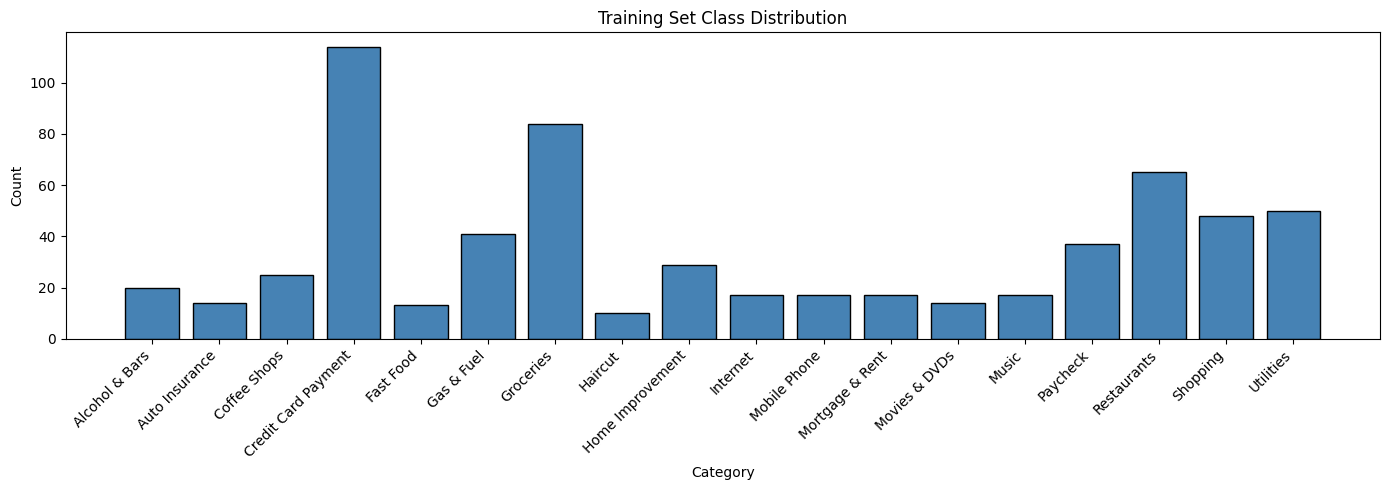

In [19]:
labels, counts = np.unique(y_train, return_counts=True)
print(f'imbalance ratio: {counts.max() / counts.min():.1f}x')

plt.figure(figsize=(14, 5))
plt.bar(class_names[labels], counts, color='steelblue', edgecolor='black')
plt.title(f'Training Set Class Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()

## 5. Model Evaluation Helper

In [ ]:
results = {}

def evaluate_model(name, model):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'\n{"="*55}')
    print(f'{name}')
    print(f'  train time : {train_time:.2f}s')
    print(f'  accuracy   : {acc:.4f}')
    print(f'  precision  : {prec:.4f} (weighted)')
    print(f'  recall     : {rec:.4f} (weighted)')
    print(f'  f1         : {f1:.4f} (weighted)')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(16, 13))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {name}', fontsize=14)
    plt.tight_layout()
    fname = f'cm_{name.replace(" ","_").replace("(","").replace(")","").lower()}.png'
    plt.savefig(fname, dpi=150)
    plt.show()

    results[name] = dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                         train_time=train_time, model=model)
    return model

## 6. Model 1: Logistic Regression
*(Sawyer Jones)*

Baseline model. Fast, interpretable, and works well on high-dimensional TF-IDF features.


Logistic Regression
  train time : 0.07s
  accuracy   : 0.9811
  precision  : 0.9874 (weighted)
  recall     : 0.9811 (weighted)
  f1         : 0.9827 (weighted)
                     precision    recall  f1-score   support

     Alcohol & Bars       1.00      1.00      1.00         5
     Auto Insurance       1.00      1.00      1.00         4
       Coffee Shops       1.00      1.00      1.00         6
Credit Card Payment       1.00      1.00      1.00        29
          Fast Food       0.60      1.00      0.75         3
         Gas & Fuel       1.00      0.91      0.95        11
          Groceries       1.00      1.00      1.00        21
            Haircut       1.00      1.00      1.00         3
   Home Improvement       1.00      1.00      1.00         7
           Internet       1.00      1.00      1.00         4
       Mobile Phone       1.00      1.00      1.00         4
    Mortgage & Rent       1.00      1.00      1.00         4
      Movies & DVDs       0.80      1.00   

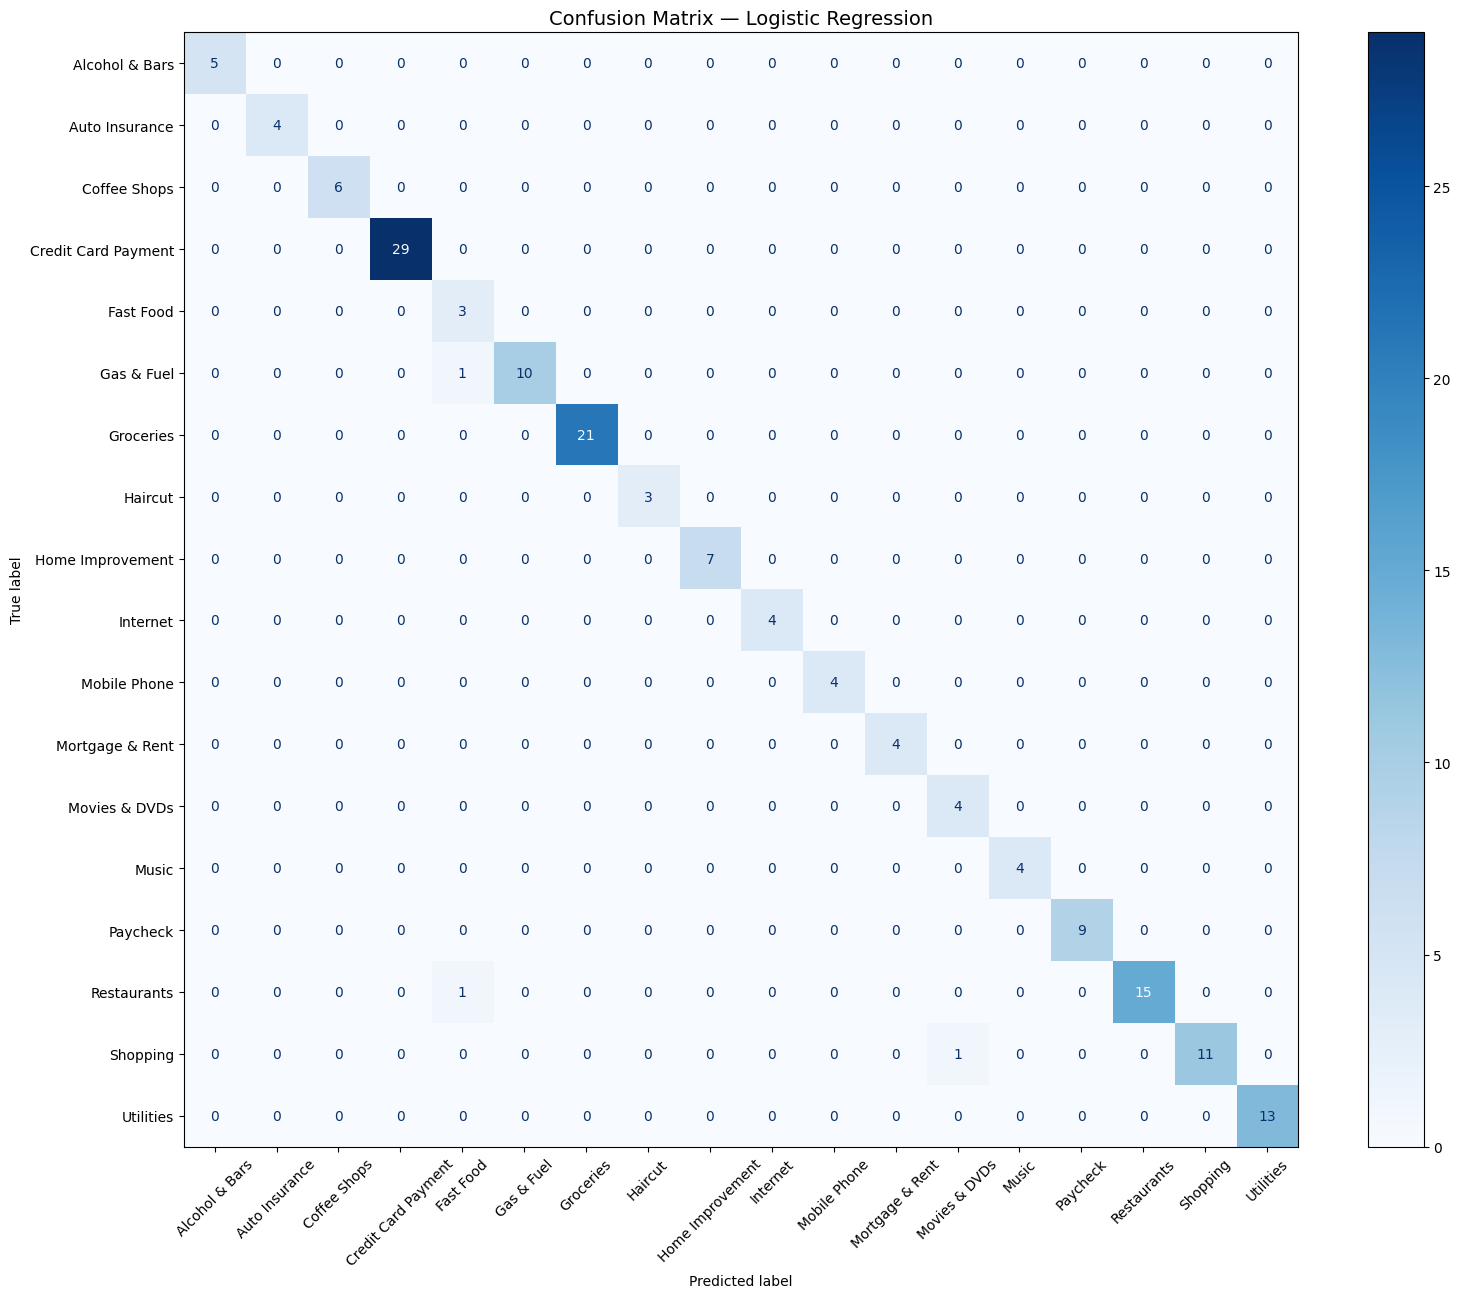

In [21]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    C=1.0,
    random_state=RANDOM_STATE
)
lr_model = evaluate_model('Logistic Regression', lr)

In [22]:
# look at which features drive each class prediction
# makes sense to verify the model is actually learning meaningful patterns
print('Top 8 features per class (LR coefficients):\n')
for i, cls in enumerate(class_names):
    top_idx = np.argsort(lr_model.coef_[i])[-8:][::-1]
    print(f'  {cls:<28}: {list(feature_names[top_idx])}')

Top 8 features per class (LR coefficients):

  Alcohol & Bars              : [np.str_('brewing'), np.str_('brewing company'), np.str_('company'), np.str_('irish'), np.str_('store'), np.str_('acct_silver card'), np.str_('american'), np.str_('american tavern')]
  Auto Insurance              : [np.str_('state'), np.str_('state farm'), np.str_('farm'), np.str_('acct_checking'), np.str_('amount'), np.str_('type_debit'), np.str_('italian restaurant'), np.str_('italian')]
  Coffee Shops                : [np.str_('starbucks'), np.str_('acct_silver card'), np.str_('mortgage payment'), np.str_('mortgage'), np.str_('biweekly'), np.str_('paycheck'), np.str_('biweekly paycheck'), np.str_('construction co')]
  Credit Card Payment         : [np.str_('credit'), np.str_('credit card'), np.str_('card payment'), np.str_('card'), np.str_('payment'), np.str_('amount'), np.str_('type_credit'), np.str_('acct_checking')]
  Fast Food                   : [np.str_('pizza place'), np.str_('pizza'), np.str_('bojan

## 7. Model 2: SVM (LinearSVC)
*(Jaden Ong)*

LinearSVC finds a maximum-margin hyperplane between classes, which works well on sparse high-dimensional data. We tune C with 5-fold CV - smaller C gives a wider margin but allows more misclassifications.

In [23]:
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
cv_f1_mean = []
cv_f1_std  = []

for c in C_values:
    m = LinearSVC(C=c, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
    scores = cross_val_score(m, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    cv_f1_mean.append(scores.mean())
    cv_f1_std.append(scores.std())
    print(f'C={c:<6}  F1={scores.mean():.4f} ± {scores.std():.4f}')

best_C = C_values[np.argmax(cv_f1_mean)]
print(f'\nbest C: {best_C}')

C=0.01    F1=0.9602 ± 0.0096
C=0.05    F1=0.9585 ± 0.0114
C=0.1     F1=0.9635 ± 0.0088
C=0.5     F1=0.9685 ± 0.0146
C=1.0     F1=0.9645 ± 0.0167
C=5.0     F1=0.9660 ± 0.0149
C=10.0    F1=0.9666 ± 0.0138

best C: 0.5


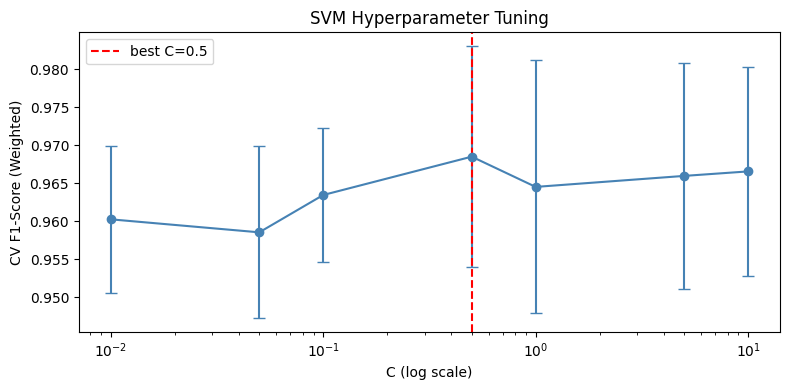

In [24]:
plt.figure(figsize=(8, 4))
plt.errorbar(C_values, cv_f1_mean, yerr=cv_f1_std, marker='o', color='steelblue', capsize=4)
plt.xscale('log')
plt.axvline(best_C, color='red', linestyle='--', label=f'best C={best_C}')
plt.xlabel('C (log scale)')
plt.ylabel('CV F1-Score (Weighted)')
plt.title('SVM Hyperparameter Tuning')
plt.legend()
plt.tight_layout()
plt.savefig('svm_hyperparameter_tuning.png', dpi=150)
plt.show()


SVM (LinearSVC)
  train time : 0.03s
  accuracy   : 0.9811
  precision  : 0.9852 (weighted)
  recall     : 0.9811 (weighted)
  f1         : 0.9817 (weighted)
                     precision    recall  f1-score   support

     Alcohol & Bars       1.00      1.00      1.00         5
     Auto Insurance       1.00      1.00      1.00         4
       Coffee Shops       1.00      1.00      1.00         6
Credit Card Payment       1.00      1.00      1.00        29
          Fast Food       1.00      1.00      1.00         3
         Gas & Fuel       0.79      1.00      0.88        11
          Groceries       1.00      1.00      1.00        21
            Haircut       1.00      1.00      1.00         3
   Home Improvement       1.00      1.00      1.00         7
           Internet       1.00      1.00      1.00         4
       Mobile Phone       1.00      1.00      1.00         4
    Mortgage & Rent       1.00      1.00      1.00         4
      Movies & DVDs       1.00      1.00      1

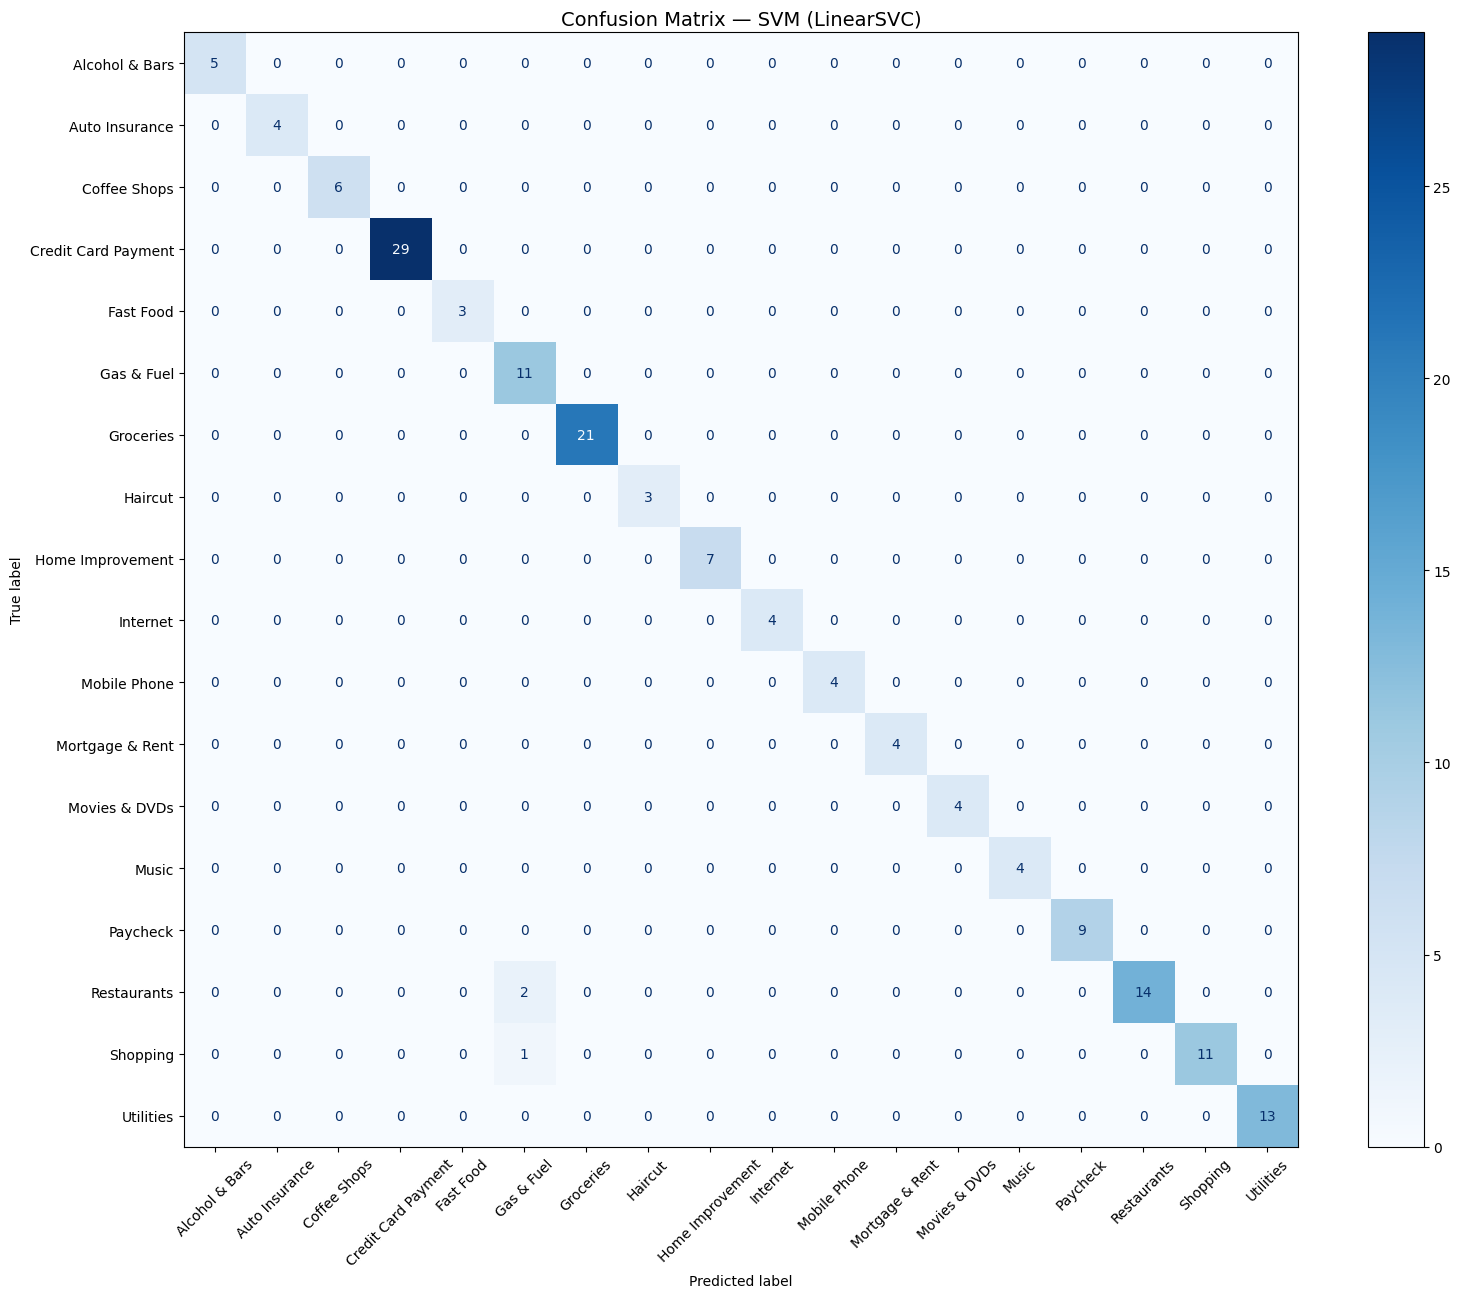

In [25]:
svm = LinearSVC(C=best_C, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
svm_model = evaluate_model('SVM (LinearSVC)', svm)

In [26]:
# per-class F1 breakdown - want to see which categories are linearly separable
y_pred_svm = svm_model.predict(X_test)
f1_svm = f1_score(y_test, y_pred_svm, average=None, labels=np.arange(n_classes), zero_division=0)

print('per-class F1 (SVM):')
for cls, score in sorted(zip(class_names, f1_svm), key=lambda x: -x[1]):
    bar = '█' * int(score * 40)
    print(f'  {cls:<30} {score:.3f}  {bar}')

per-class F1 (SVM):
  Alcohol & Bars                 1.000  ████████████████████████████████████████
  Auto Insurance                 1.000  ████████████████████████████████████████
  Coffee Shops                   1.000  ████████████████████████████████████████
  Credit Card Payment            1.000  ████████████████████████████████████████
  Fast Food                      1.000  ████████████████████████████████████████
  Groceries                      1.000  ████████████████████████████████████████
  Haircut                        1.000  ████████████████████████████████████████
  Home Improvement               1.000  ████████████████████████████████████████
  Internet                       1.000  ████████████████████████████████████████
  Mobile Phone                   1.000  ████████████████████████████████████████
  Mortgage & Rent                1.000  ████████████████████████████████████████
  Movies & DVDs                  1.000  ████████████████████████████████████████
  Music 

## 8. Model 3: Neural Network (MLP)
*(Ian Hock)*

Three hidden layers (256, 128, 64) with ReLU and Adam. Early stopping on a 10% validation split to avoid overfitting. Can pick up non-linear patterns that LR and SVM miss.


Neural Network (MLP)
  train time : 1.67s
  accuracy   : 0.9434
  precision  : 0.9233 (weighted)
  recall     : 0.9434 (weighted)
  f1         : 0.9296 (weighted)
                     precision    recall  f1-score   support

     Alcohol & Bars       1.00      1.00      1.00         5
     Auto Insurance       1.00      1.00      1.00         4
       Coffee Shops       0.86      1.00      0.92         6
Credit Card Payment       1.00      1.00      1.00        29
          Fast Food       0.00      0.00      0.00         3
         Gas & Fuel       0.61      1.00      0.76        11
          Groceries       1.00      1.00      1.00        21
            Haircut       0.00      0.00      0.00         3
   Home Improvement       1.00      1.00      1.00         7
           Internet       1.00      1.00      1.00         4
       Mobile Phone       1.00      1.00      1.00         4
    Mortgage & Rent       1.00      1.00      1.00         4
      Movies & DVDs       1.00      1.00  

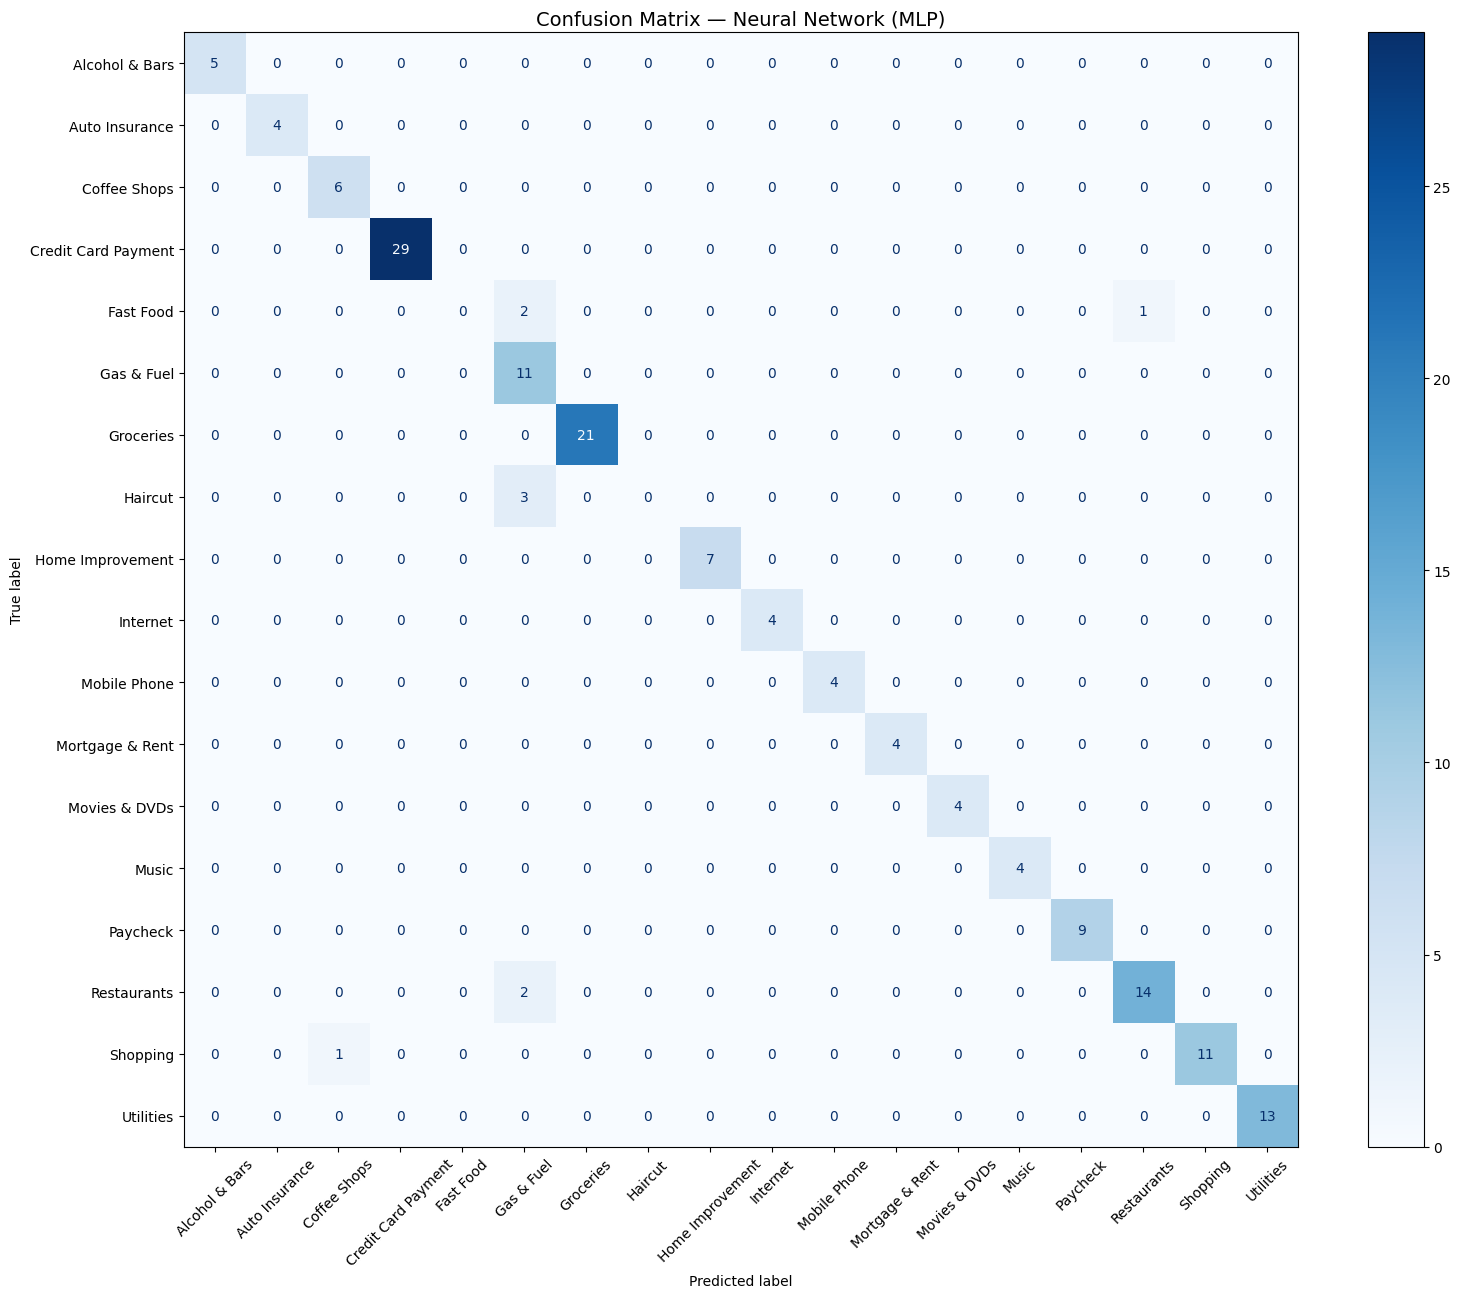

In [27]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
    verbose=False
)
mlp_model = evaluate_model('Neural Network (MLP)', mlp)

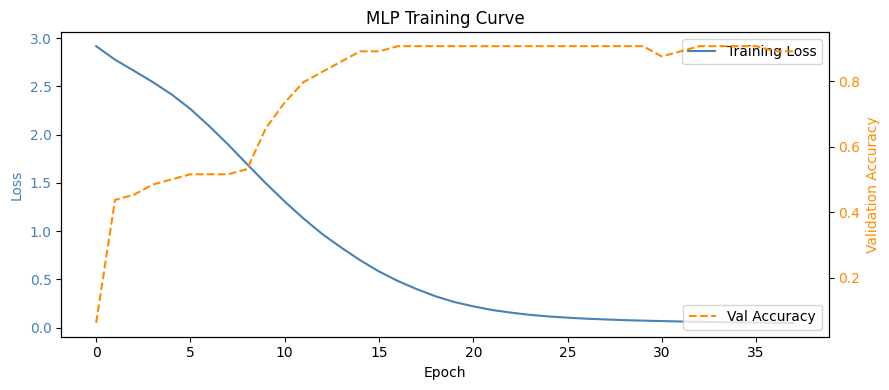

stopped at epoch 38


In [28]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(mlp_model.loss_curve_, color='steelblue', label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

if mlp_model.validation_scores_:
    ax2 = ax1.twinx()
    ax2.plot(mlp_model.validation_scores_, color='darkorange', linestyle='--', label='Val Accuracy')
    ax2.set_ylabel('Validation Accuracy', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.legend(loc='lower right')

ax1.set_title('MLP Training Curve')
ax1.legend(loc='upper right')
plt.tight_layout()
plt.savefig('mlp_training_curve.png', dpi=150)
plt.show()
print(f'stopped at epoch {mlp_model.n_iter_}')

## 9. Model 4: KNN
*(Justin Pelak)*

Classifies by majority vote among the K nearest neighbors. We use cosine distance since it works better than Euclidean on sparse TF-IDF vectors. K is tuned with 5-fold CV.

In [29]:
k_values = [1, 3, 5, 7, 10, 15, 20]
knn_cv_mean = []
knn_cv_std  = []

for k in k_values:
    knn_cv = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    knn_cv_mean.append(scores.mean())
    knn_cv_std.append(scores.std())
    print(f'K={k:<3}  F1={scores.mean():.4f} ± {scores.std():.4f}')

best_k = k_values[np.argmax(knn_cv_mean)]
print(f'\nbest K: {best_k}')

K=1    F1=0.9526 ± 0.0182
K=3    F1=0.9399 ± 0.0245
K=5    F1=0.9454 ± 0.0195
K=7    F1=0.9415 ± 0.0175
K=10   F1=0.9337 ± 0.0155
K=15   F1=0.9003 ± 0.0249
K=20   F1=0.8462 ± 0.0219

best K: 1


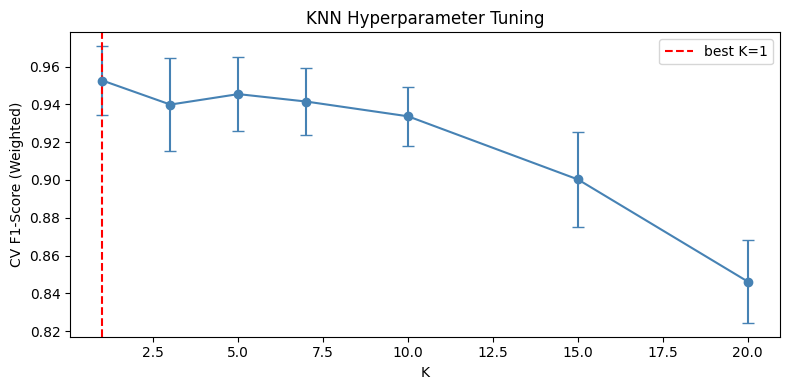

In [30]:
plt.figure(figsize=(8, 4))
plt.errorbar(k_values, knn_cv_mean, yerr=knn_cv_std, marker='o', color='steelblue', capsize=4)
plt.axvline(best_k, color='red', linestyle='--', label=f'best K={best_k}')
plt.xlabel('K')
plt.ylabel('CV F1-Score (Weighted)')
plt.title('KNN Hyperparameter Tuning')
plt.legend()
plt.tight_layout()
plt.savefig('knn_hyperparameter_tuning.png', dpi=150)
plt.show()


KNN
  train time : 0.01s
  accuracy   : 0.9623
  precision  : 0.9728 (weighted)
  recall     : 0.9623 (weighted)
  f1         : 0.9643 (weighted)
                     precision    recall  f1-score   support

     Alcohol & Bars       1.00      1.00      1.00         5
     Auto Insurance       1.00      1.00      1.00         4
       Coffee Shops       1.00      0.83      0.91         6
Credit Card Payment       1.00      1.00      1.00        29
          Fast Food       0.50      1.00      0.67         3
         Gas & Fuel       0.91      0.91      0.91        11
          Groceries       0.91      1.00      0.95        21
            Haircut       1.00      1.00      1.00         3
   Home Improvement       1.00      1.00      1.00         7
           Internet       1.00      1.00      1.00         4
       Mobile Phone       1.00      1.00      1.00         4
    Mortgage & Rent       1.00      1.00      1.00         4
      Movies & DVDs       1.00      1.00      1.00         

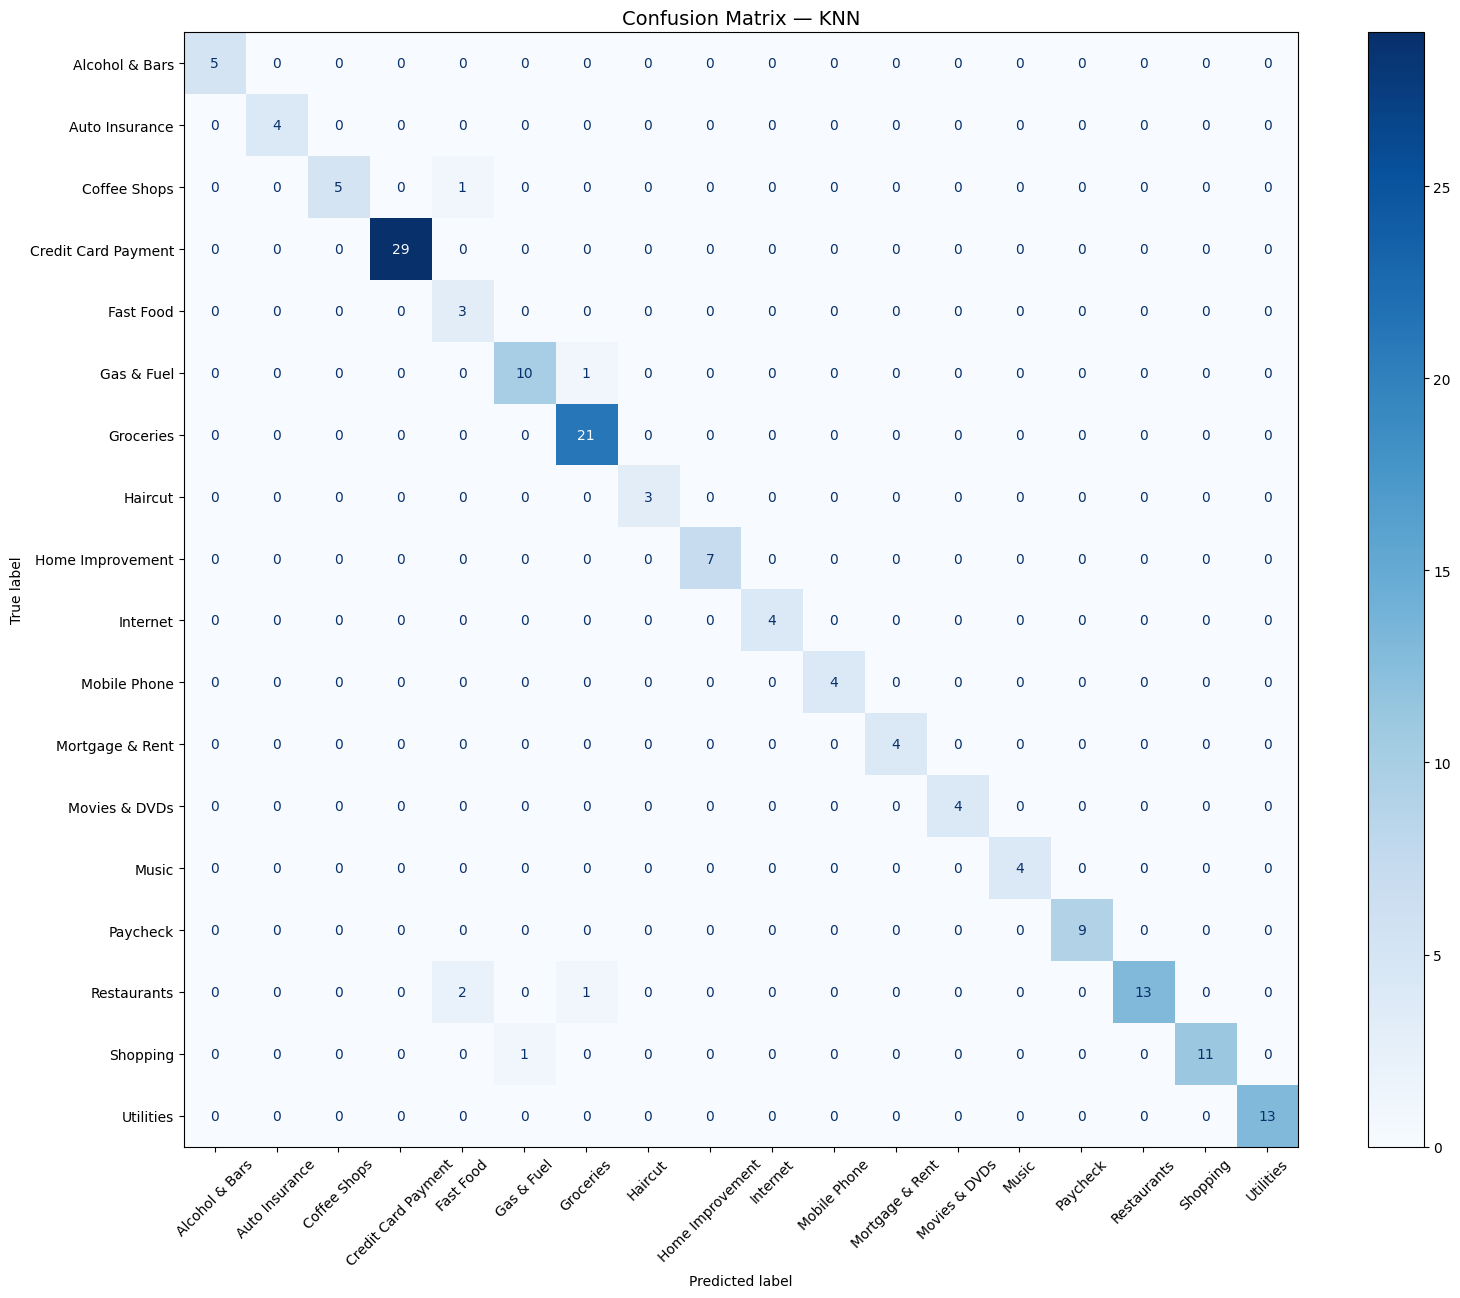

In [31]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_model = evaluate_model('KNN', knn)

## 10. Comparative Analysis
*(Justin Pelak)*

In [32]:
summary = pd.DataFrame([
    {
        'Model':          name,
        'Accuracy':       round(v['accuracy'],  4),
        'Precision':      round(v['precision'], 4),
        'Recall':         round(v['recall'],    4),
        'F1 (weighted)':  round(v['f1'],        4),
        'Train Time (s)': round(v['train_time'], 2),
    }
    for name, v in results.items()
]).set_index('Model')

print(summary.to_string())
summary

                      Accuracy  Precision  Recall  F1 (weighted)  Train Time (s)
Model                                                                           
Logistic Regression     0.9811     0.9874  0.9811         0.9827            0.07
SVM (LinearSVC)         0.9811     0.9852  0.9811         0.9817            0.03
Neural Network (MLP)    0.9434     0.9233  0.9434         0.9296            1.67
KNN                     0.9623     0.9728  0.9623         0.9643            0.01


,Accuracy,Precision,Recall,F1 (weighted),Train Time (s)
Model,,,,,
Logistic Regression,0.9811,0.9874,0.9811,0.9827,0.07
SVM (LinearSVC),0.9811,0.9852,0.9811,0.9817,0.03
Neural Network (MLP),0.9434,0.9233,0.9434,0.9296,1.67
KNN,0.9623,0.9728,0.9623,0.9643,0.01


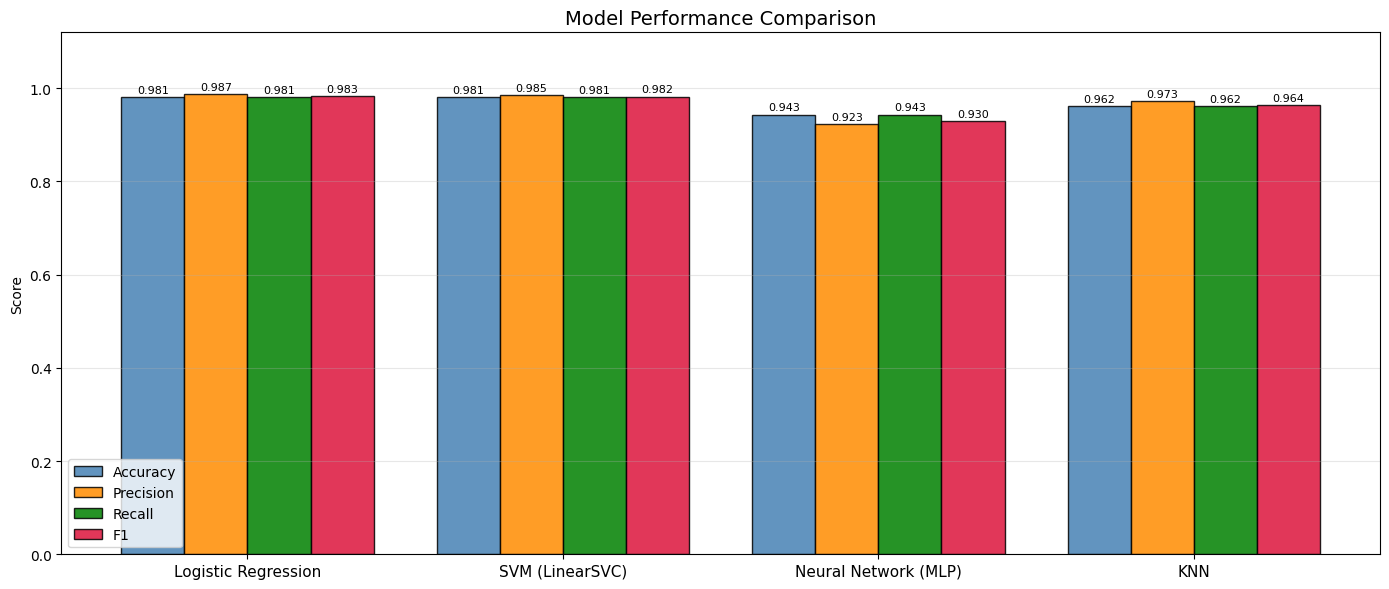

In [33]:
metrics       = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names   = list(results.keys())
colors        = ['steelblue', 'darkorange', 'green', 'crimson']
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=label,
                  color=colors[i], alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

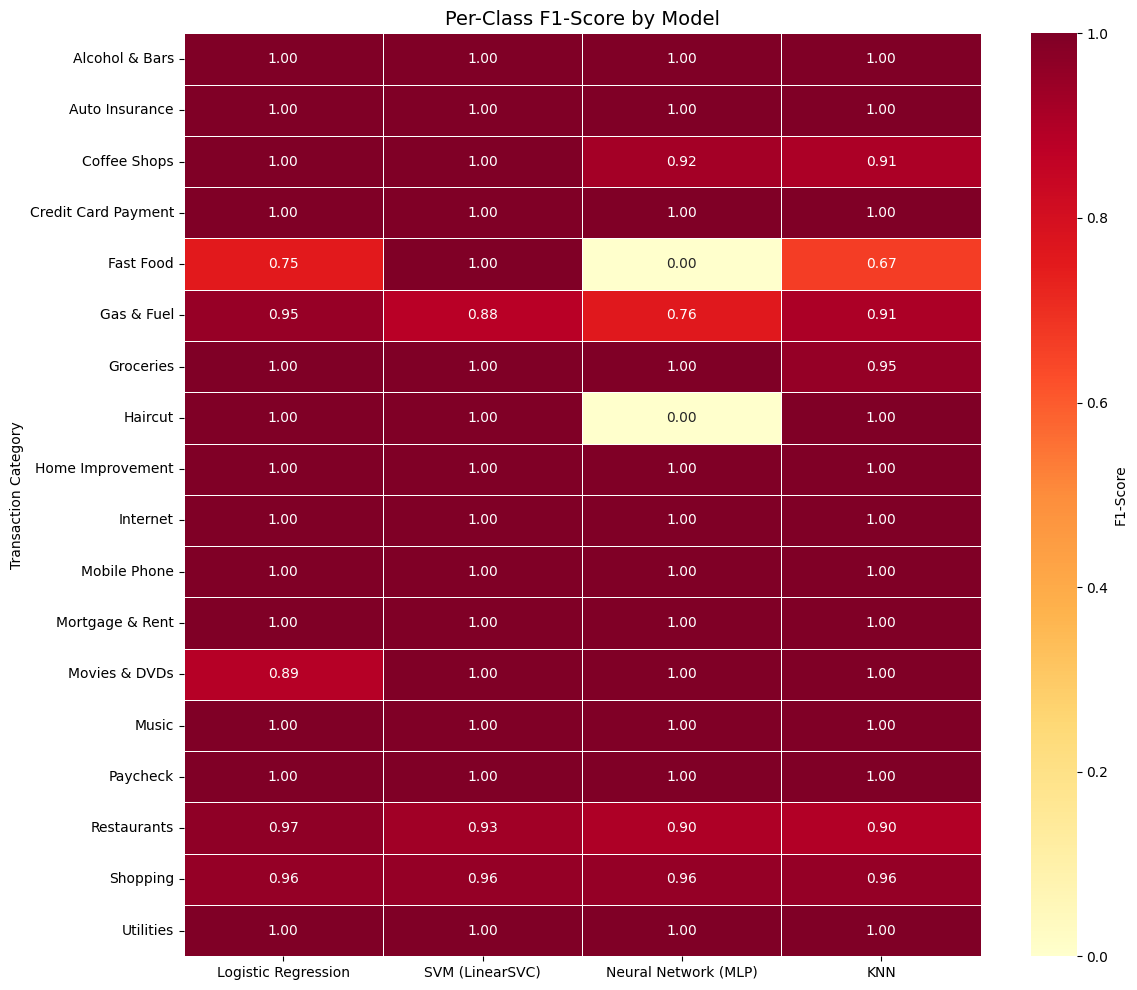

In [34]:
# per-class F1 heatmap to see where each model struggles
model_map = {
    'Logistic Regression':  lr_model,
    'SVM (LinearSVC)':      svm_model,
    'Neural Network (MLP)': mlp_model,
    'KNN':                  knn_model,
}

heatmap_data = {}
for name, model in model_map.items():
    y_pred_tmp = model.predict(X_test)
    f1s = f1_score(y_test, y_pred_tmp, average=None,
                   labels=np.arange(n_classes), zero_division=0)
    heatmap_data[name] = f1s

f1_df = pd.DataFrame(heatmap_data, index=class_names)

plt.figure(figsize=(12, 10))
sns.heatmap(f1_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label': 'F1-Score'})
plt.title('Per-Class F1-Score by Model', fontsize=14)
plt.ylabel('Transaction Category')
plt.tight_layout()
plt.savefig('per_class_f1_heatmap.png', dpi=150)
plt.show()

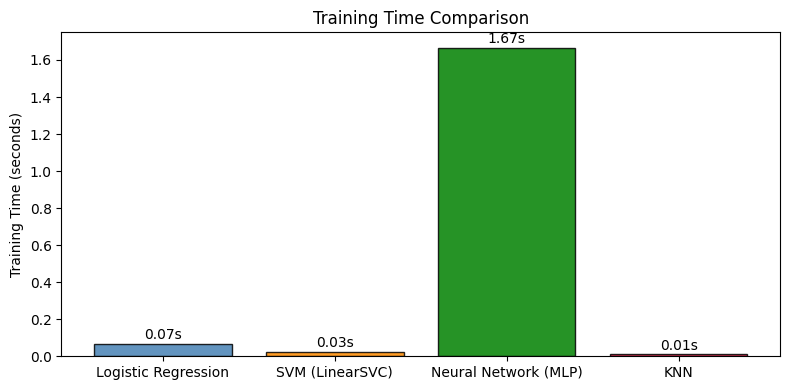

In [35]:
times = {name: v['train_time'] for name, v in results.items()}

plt.figure(figsize=(8, 4))
bars = plt.bar(times.keys(), times.values(),
               color=['steelblue', 'darkorange', 'green', 'crimson'],
               edgecolor='black', alpha=0.85)
for bar, t in zip(bars, times.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{t:.2f}s', ha='center', va='bottom', fontsize=10)
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison')
plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=150)
plt.show()

In [36]:
best_name = max(results, key=lambda k: results[k]['f1'])
best = results[best_name]
print(f'best model: {best_name}')
print(f'  F1:       {best["f1"]:.4f}')
print(f'  accuracy: {best["accuracy"]:.4f}')
print(f'  time:     {best["train_time"]:.2f}s')

best model: Logistic Regression
  F1:       0.9827
  accuracy: 0.9811
  time:     0.07s


## 11. Discussion

### Results summary

LR and SVM both hit ~98% accuracy while MLP and KNN came in around 94% and 96%. The linear models doing this well makes sense given the data - merchant descriptions like "Netflix", "Spotify", and "Mortgage Payment" are pretty unique to a single category, so TF-IDF alone gives the models a lot to work with.

MLP underperforming LR and SVM is not surprising with only ~630 training samples. It would likely close the gap with more data.

### Where models struggled

The per-class heatmap shows the most consistent errors in:
- **Restaurants / Fast Food / Alcohol & Bars**: overlapping venue-style names
- **Gas & Fuel**: slightly lower F1 across all models, probably because "Gas Company" could read as a utility

### Dataset note

The raw CSV has 10,806 rows but only 806 have valid User IDs with correct labels. The other 10,000 have randomly shuffled categories (Netflix labeled as Coffee Shops, State Farm as Restaurants, etc.) and were dropped during preprocessing. All results use the 791-row clean subset.

### Limitations
- Small labeled set, more data would help all models especially MLP
- Descriptions in this dataset are clean; real bank transaction strings are much noisier
- We did not use any date-based features, which could help catch recurring subscriptions